# Robustness Experiments — Attacks & Defenses

Tests the federated PIDL model against data-poisoning attacks and the
update-clipping defense. Results are saved under `results_robustness/`.

**Run after notebook 01** (datasets are already downloaded and cached).

| Experiment | Description |
|---|---|
| Clean baseline | No attack, no defense |
| Gaussian noise | 1 malicious client adds Gaussian noise to images |
| Label flip | 1 malicious client flips 30 % of labels |
| Noise + clipping | Gaussian noise attack + update-clipping defense |
| Label flip + clipping | Label-flip attack + update-clipping defense |

---
## § 1 — Setup

In [1]:
# ── Edit your GitHub repo URL here ───────────────────────────────────
GITHUB_REPO = 'https://github.com/PulockDas/medical_fl_pidl.git'
# ──────────────────────────────────────────────────────────────────────

import gc, json, os, sys, time
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch

PROJECT_ROOT = Path('/content/medical_fl_pidl')
if not PROJECT_ROOT.exists():
    os.system(f'git clone {GITHUB_REPO} {PROJECT_ROOT}')
else:
    os.system(f'git -C {PROJECT_ROOT} pull')

sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

RESULTS_ROOT = PROJECT_ROOT / 'results_robustness'
FIGURES_DIR  = RESULTS_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

!pip install -q --upgrade pip setuptools wheel
!pip install -q -r requirements.txt

plt.rcParams.update({
    'font.family':'serif','font.size':11,'axes.labelsize':12,
    'axes.titlesize':13,'figure.dpi':150,'savefig.dpi':300,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,
    'figure.constrained_layout.use':True,
})

WONG = ['#E69F00','#56B4E9','#009E73','#F0E442','#0072B2','#D55E00','#CC79A7','#000000']

def savefig(name):
    p = FIGURES_DIR / f'{name}.png'
    plt.savefig(p, bbox_inches='tight', dpi=300)
    print(f'  Saved: {p.name}')

print('Setup complete.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 71.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer-slim 0.24.0 requires typer>=0.24.0, but you have typer 0.20.1 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 46.0.7 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 46.0.7 which is incompatible.
google-ai-generativelanguage 0.

In [5]:
import kagglehub
from data.kaggle_loader import find_image_root
# Re-download (fast if already cached from this session, otherwise re-fetches)
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
DATA_ROOT = str(find_image_root(path))
print(f"DATA_ROOT = {DATA_ROOT!r}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
[find_image_root] Found (named training split): 'Training'
  Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
DATA_ROOT = '/kaggle/input/brain-tumor-mri-dataset/Training'


---
## § 2 — Dataset & Experiment Config

In [6]:
# Choose ONE dataset for robustness experiments.
# The data root must already be downloaded (notebook 01 caches it).
DATASET_NAME = 'brain_tumor_mri'   # or 'colon_cancer_or_pathology' / 'covid'

# FL settings (keep small for speed)
NUM_CLIENTS   = 3
NUM_ROUNDS    = 5
LOCAL_EPOCHS  = 2

# Attack settings
MALICIOUS_IDS = [0]       # client 0 is the attacker in all attack experiments
NOISE_STD     = 0.8       # Gaussian noise std (normalised pixel space)
FLIP_PROB     = 0.30      # fraction of labels to flip

# Defense settings
CLIP_NORM     = 3.0       # max L2 norm of client update

print(f'Dataset : {DATASET_NAME}')
print(f'Data root : {DATA_ROOT}')
print(f'Clients : {NUM_CLIENTS}  |  Rounds : {NUM_ROUNDS}  |  Local epochs : {LOCAL_EPOCHS}')
print(f'Attacker clients : {MALICIOUS_IDS}  |  noise_std={NOISE_STD}  flip_prob={FLIP_PROB}')
print(f'Clip norm : {CLIP_NORM}')


Dataset : brain_tumor_mri
Data root : /kaggle/input/brain-tumor-mri-dataset/Training
Clients : 3  |  Rounds : 5  |  Local epochs : 2
Attacker clients : [0]  |  noise_std=0.8  flip_prob=0.3
Clip norm : 3.0


---
## § 3 — Experiment Runner

In [7]:
from flwr.simulation import run_simulation
from federated.server_app import app as _server_app
from federated.client_app import _make_client_app

def run_robustness_experiment(
    experiment_name: str,
    enable_attack:          bool  = False,
    attack_type:            str   = 'gaussian_noise',
    enable_update_clipping: bool  = False,
) -> dict:
    """Run one robustness experiment and return a summary dict."""
    log_dir = RESULTS_ROOT / DATASET_NAME / experiment_name
    log_dir.mkdir(parents=True, exist_ok=True)

    run_cfg = {
        # Core FL
        'dataset_name':      DATASET_NAME,
        'data_root':         DATA_ROOT,
        'log_dir':           str(log_dir),
        'num_clients':       NUM_CLIENTS,
        'num_server_rounds': NUM_ROUNDS,
        'min_fit_clients':   NUM_CLIENTS,
        'local_epochs':      LOCAL_EPOCHS,
        'batch_size':        32,
        'learning_rate':     0.001,
        'image_size':        224,
        'feature_layer':     'layer2',
        'regularizer_type':  'perona_malik',
        'lambda_pm':         0.1,
        'use_grid_loss':     True,
        'grid_size':         4,
        'k':                 1.0,
        'random_seed':       42,
        'use_secagg':        False,
        # Robustness
        'enable_attack':            enable_attack,
        'attack_type':              attack_type,
        'malicious_client_ids':     ','.join(str(i) for i in MALICIOUS_IDS),
        'noise_std':                NOISE_STD,
        'label_flip_probability':   FLIP_PROB,
        'enable_update_clipping':   enable_update_clipping,
        'clip_norm':                CLIP_NORM,
    }

    # Write config
    (log_dir / 'config.json').write_text(json.dumps(run_cfg, indent=2))

    os.environ['FL_RUN_OVERRIDE'] = json.dumps(run_cfg)
    _client_app = _make_client_app()

    gpu_frac = 0.5 if torch.cuda.is_available() else 0.0
    backend_cfg = {'client_resources': {'num_cpus': 2, 'num_gpus': gpu_frac}}

    print(f'\n--- {experiment_name} ---')
    t0 = time.time()
    try:
        run_simulation(
            server_app    =_server_app,
            client_app    =_client_app,
            num_supernodes=NUM_CLIENTS,
            backend_config=backend_cfg,
        )
        elapsed = time.time() - t0
        print(f'  Done in {elapsed:.0f}s')
    except Exception as exc:
        print(f'  FAILED: {exc}')
        import traceback; traceback.print_exc()
        return {'experiment': experiment_name, 'error': str(exc)}
    finally:
        os.environ.pop('FL_RUN_OVERRIDE', None)

    # Build summary from fl_rounds.csv
    csv_path = log_dir / 'fl_rounds.csv'
    jsonl_path = log_dir / 'round_metrics.jsonl'
    summary = {'experiment': experiment_name, 'elapsed_sec': round(elapsed, 1)}

    if csv_path.exists():
        df = pd.read_csv(csv_path)
        df = df[df['round'] > 0]
        if not df.empty:
            last = df.iloc[-1]
            summary.update({
                'final_accuracy':    round(float(last['global_test_acc']),  4),
                'best_accuracy':     round(float(df['global_test_acc'].max()), 4),
                'final_macro_f1':    round(float(last['f1_macro']),         4),
                'final_ece':         round(float(last['ece']),              4),
                'final_loss':        round(float(last['global_test_loss']), 4),
            })

    # Pull secagg / training times and ce/reg losses from JSONL
    if jsonl_path.exists():
        lines = jsonl_path.read_text().strip().splitlines()
        recent = [json.loads(l) for l in lines[-NUM_ROUNDS:]]
        summary['secagg_overhead_mean_sec'] = round(
            sum(r.get('secagg_overhead_sec',0) for r in recent) / max(len(recent),1), 4)
        summary['train_ce_loss_final']  = round(recent[-1].get('train_ce_loss', 0), 4)  if recent else 0
        summary['train_reg_loss_final'] = round(recent[-1].get('train_pidl_loss', 0), 4) if recent else 0

    (log_dir / 'robustness_summary.json').write_text(json.dumps(summary, indent=2))
    print(f'  acc={summary.get("final_accuracy","?")}')
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return summary

print('run_robustness_experiment() defined.')


run_robustness_experiment() defined.


---
## § 4 — Run All 5 Experiments

In [8]:
EXPERIMENTS = [
    # (name,              enable_attack, attack_type,      enable_clipping)
    ('clean',             False,         'gaussian_noise', False),
    ('noisy_client',      True,          'gaussian_noise', False),
    ('label_flip',        True,          'label_flip',     False),
    ('noisy_clipped',     True,          'gaussian_noise', True),
    ('label_flip_clipped',True,          'label_flip',     True),
]

all_results = []
for name, atk, atype, clip in EXPERIMENTS:
    result = run_robustness_experiment(
        experiment_name        =name,
        enable_attack          =atk,
        attack_type            =atype,
        enable_update_clipping =clip,
    )
    all_results.append(result)

results_df = pd.DataFrame(all_results).set_index('experiment')
results_df.to_csv(RESULTS_ROOT / 'robustness_comparison.csv')
print('\nAll experiments complete.')
print(results_df[['final_accuracy','best_accuracy','final_macro_f1','final_ece']].to_string())



            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        



--- clean ---
[Server] Device: cuda  |  Log dir: /content/medical_fl_pidl/results_robustness/brain_tumor_mri/clean
[task] Building federated data for 3 clients from: /kaggle/input/brain-tumor-mri-dataset/Training
[build_federated_dataloaders] Loading ImageFolder from '/kaggle/input/brain-tumor-mri-dataset/Training' …


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  → 5,600 images  |  4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
  → Grayscale source detected. Images will be converted to 3-channel RGB.
  → Split: 4,480 train  |  1,120 test  (stratified, seed=42)
  → Partitioning (iid): client 0: 1,496  |  client 1: 1,492  |  client 2: 1,492
[dataset_utils] Summary saved → /content/medical_fl_pidl/results_robustness/brain_tumor_mri/clean/dataset_summary.json
[build_federated_dataloaders] Done. 3 client loaders + 1 test loader ready.

[Server] Dataset  : brain_tumor_mri  (4 classes: ['glioma', 'meningioma', 'notumor', 'pituitary'])
[Server] Test set : 1120 samples


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

INFO :      aggregate_fit: received 3 results and 0 failures
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.pin_memory() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:46.)
  return data.pin_memory(device)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py:57: DeprecationWarning: The argument 'device' of Tensor.is_pinned() is deprecated. Please do not pass this argument. (Triggered internally at /pytorch/aten/src/ATen/native/Memory.cpp:31.)
  return data.pin_memory(device)
INFO :      fit progress: (5, 1.3393050295966011, {'accuracy': 0.3776785714285714, 'num_samples': 1120, 'f1_macro': 0.3459334674493678, 'balanced_accuracy': 0.3776785714285714, 'ece': 0.0581805652539645}, 670.5078917129999)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow(

[Server Eval] Round   5 | Loss: 1.3393  Acc: 37.77%  N=1120
(ClientAppActor pid=20079) [Robustness] Client 0 is MALICIOUS — attack=label_flip


INFO :      aggregate_evaluate: received 3 results and 0 failures
INFO :      
INFO :      [SUMMARY]
INFO :      Run finished 5 round(s) in 691.97s
INFO :      	History (loss, distributed):
INFO :      		round 1: 1.629305921282087
INFO :      		round 2: 1.5359300681522914
INFO :      		round 3: 1.4467393909181867
INFO :      		round 4: 1.3855230910437448
INFO :      		round 5: 1.3393050295966011
INFO :      	History (loss, centralized):
INFO :      		round 0: 1.7596654312951223
INFO :      		round 1: 1.629305921282087
INFO :      		round 2: 1.5359300681522914
INFO :      		round 3: 1.4467393909181867
INFO :      		round 4: 1.3855230910437448
INFO :      		round 5: 1.3393050295966011
INFO :      	History (metrics, centralized):
INFO :      	{'accuracy': [(0, 0.29910714285714285),
INFO :      	              (1, 0.3107142857142857),
INFO :      	              (2, 0.3196428571428571),
INFO :      	              (3, 0.33839285714285716),
INFO :      	              (4, 0.36160714285714285),


Round   5 | Train Acc: 68.94%  Loss: 0.8787  PIDL: 0.043528 | Client Val Acc: 37.77%  Loss: 1.3393 |  Server Acc: 37.77% | Elapsed: 134.0s
  Done in 716s
  acc=0.3777

All experiments complete.
                    final_accuracy  best_accuracy  final_macro_f1  final_ece
experiment                                                                  
clean                       0.9545         0.9545          0.9543     0.0103
noisy_client                0.9518         0.9518          0.9518     0.0158
label_flip                  0.9196         0.9232          0.9193     0.1098
noisy_clipped               0.3402         0.3402          0.2567     0.1308
label_flip_clipped          0.3777         0.3777          0.3459     0.0582


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## § 5 — Plots

  Saved: 01_accuracy_f1_curves.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


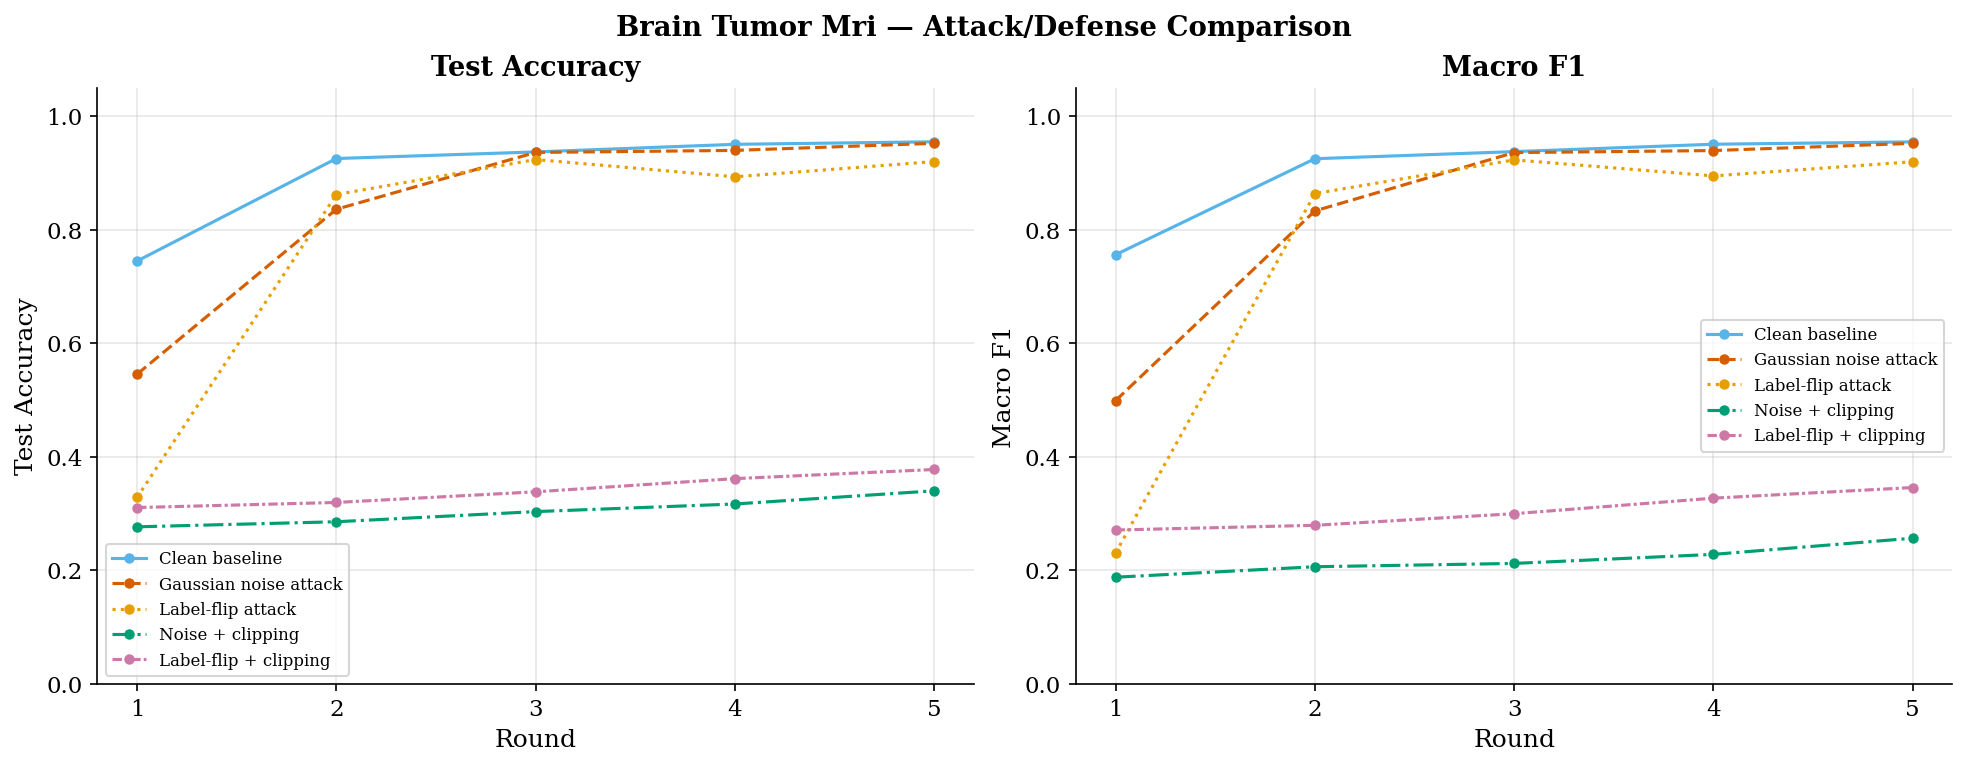

  Saved: 02_final_metrics_bar.png


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


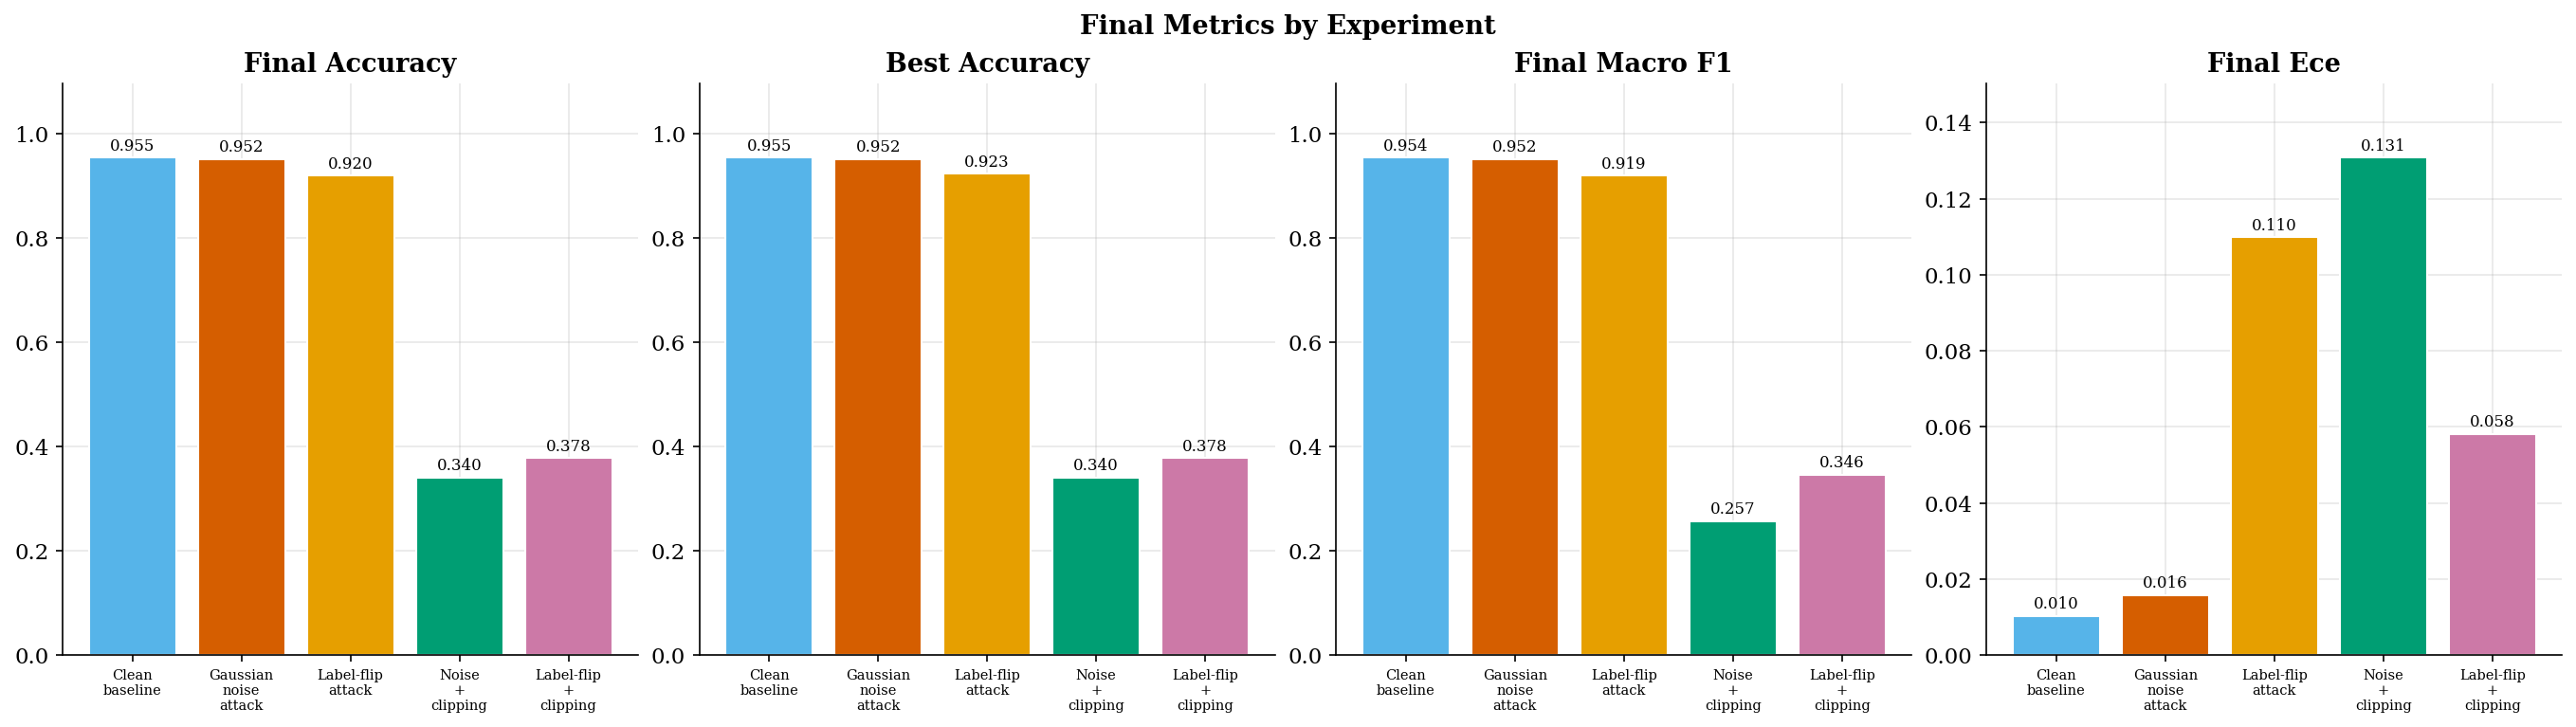

  Saved: 03_loss_decomposition.png


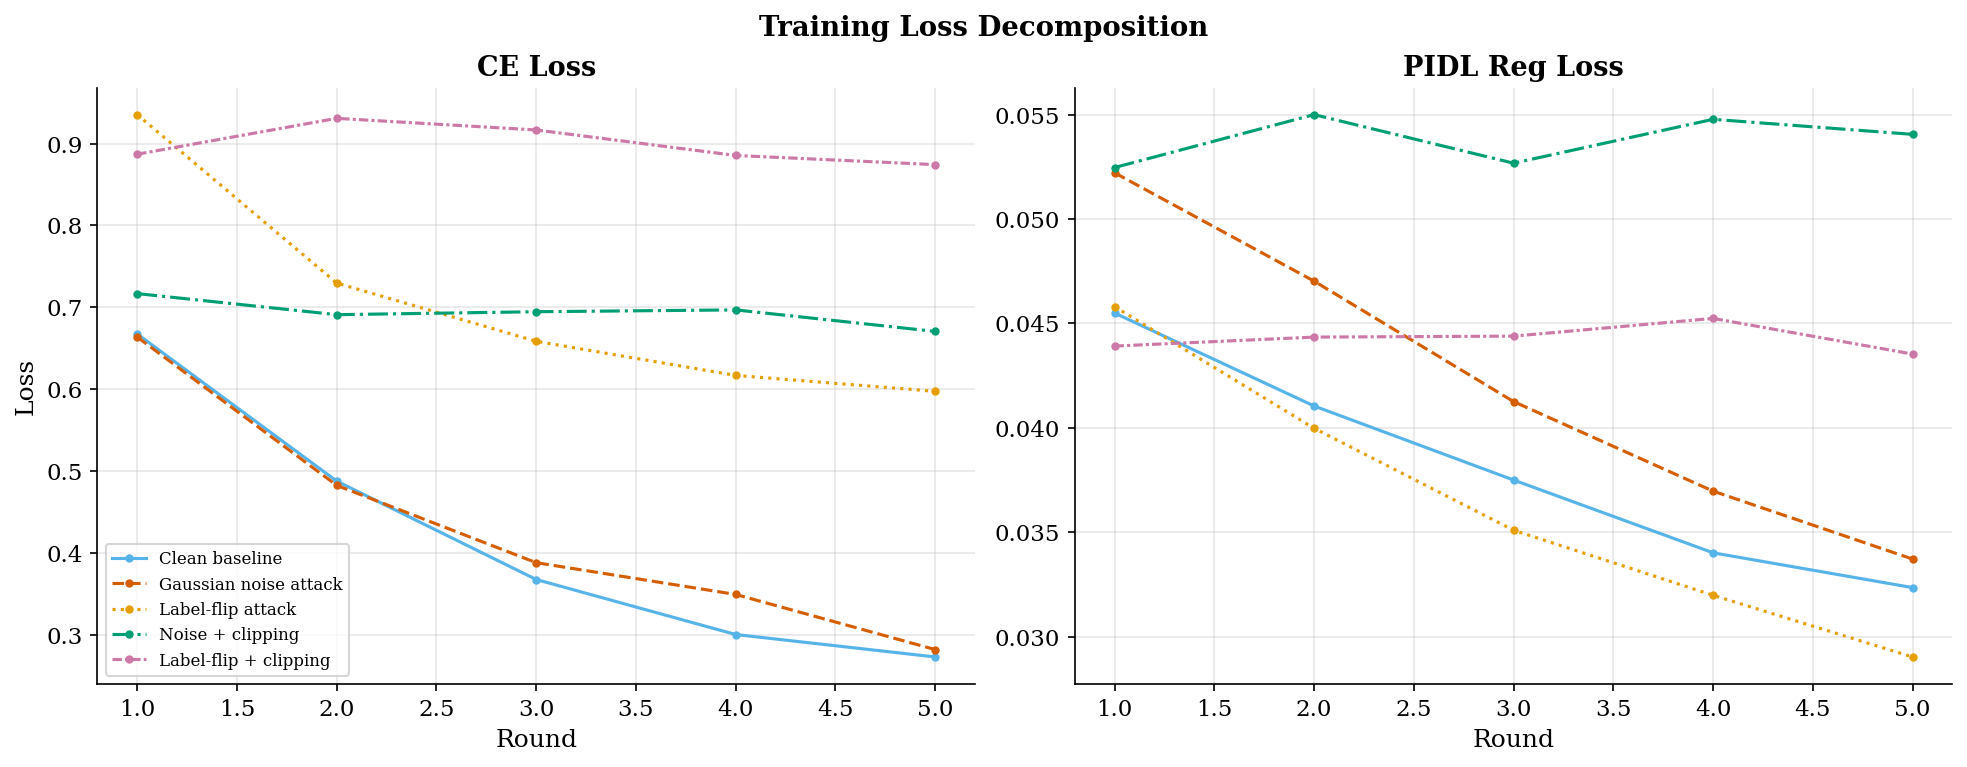

All plots saved to /content/medical_fl_pidl/results_robustness/figures


In [9]:
# ── Load per-round data for training curves ───────────────────────────
EXP_COLORS = {
    'clean':              WONG[1],
    'noisy_client':       WONG[5],
    'label_flip':         WONG[0],
    'noisy_clipped':      WONG[2],
    'label_flip_clipped': WONG[6],
}
EXP_LS = {
    'clean':'-','noisy_client':'--','label_flip':':',
    'noisy_clipped':'-.','label_flip_clipped':(0,(3,1,1,1)),
}
LABEL = {
    'clean':'Clean baseline',
    'noisy_client':'Gaussian noise attack',
    'label_flip':'Label-flip attack',
    'noisy_clipped':'Noise + clipping',
    'label_flip_clipped':'Label-flip + clipping',
}

per_round = {}
for name, *_ in EXPERIMENTS:
    csv = RESULTS_ROOT / DATASET_NAME / name / 'fl_rounds.csv'
    if csv.exists():
        df = pd.read_csv(csv)
        per_round[name] = df[df['round'] > 0].reset_index(drop=True)

# ── Plot 1: Accuracy & F1 over rounds ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'{DATASET_NAME.replace("_"," ").title()} — Attack/Defense Comparison', fontweight='bold')

for exp, df in per_round.items():
    c  = EXP_COLORS.get(exp, 'gray')
    ls = EXP_LS.get(exp, '-')
    lb = LABEL.get(exp, exp)
    axes[0].plot(df['round'], df['global_test_acc'], color=c, ls=ls, marker='o', markersize=4, label=lb)
    axes[1].plot(df['round'], df['f1_macro'],        color=c, ls=ls, marker='o', markersize=4, label=lb)

for ax, title in zip(axes, ['Test Accuracy', 'Macro F1']):
    ax.set_xlabel('Round'); ax.set_ylabel(title)
    ax.set_title(title, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=8)

savefig('01_accuracy_f1_curves')
plt.show()

# ── Plot 2: Final metrics bar chart ───────────────────────────────────
if not results_df.empty and 'final_accuracy' in results_df.columns:
    metrics_to_plot = ['final_accuracy','best_accuracy','final_macro_f1','final_ece']
    available = [m for m in metrics_to_plot if m in results_df.columns]
    fig, axes = plt.subplots(1, len(available), figsize=(4.5*len(available), 5))
    if len(available) == 1: axes = [axes]
    fig.suptitle('Final Metrics by Experiment', fontweight='bold')

    for ax, metric in zip(axes, available):
        vals = results_df[metric].dropna()
        colors = [EXP_COLORS.get(i, 'gray') for i in vals.index]
        bars = ax.bar(range(len(vals)), vals.values, color=colors, edgecolor='white')
        ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)
        ax.set_title(metric.replace('_',' ').title(), fontweight='bold')
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels([LABEL.get(i,i).replace(' ','\n') for i in vals.index], fontsize=7)
        ax.set_ylim(0, max(vals.max()*1.15, 0.1))
        ax.set_axisbelow(True)

    savefig('02_final_metrics_bar')
    plt.show()

# ── Plot 3: Training loss (CE vs PIDL reg) ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Training Loss Decomposition', fontweight='bold')

for exp in per_round:
    jsonl = RESULTS_ROOT / DATASET_NAME / exp / 'round_metrics.jsonl'
    if not jsonl.exists(): continue
    lines = jsonl.read_text().strip().splitlines()
    recs  = [json.loads(l) for l in lines[-NUM_ROUNDS:]]
    rounds   = [r['round'] for r in recs]
    ce_loss  = [r.get('train_ce_loss', 0) for r in recs]
    reg_loss = [r.get('train_pidl_loss', 0) for r in recs]
    c = EXP_COLORS.get(exp, 'gray')
    ls = EXP_LS.get(exp, '-')
    lb = LABEL.get(exp, exp)
    axes[0].plot(rounds, ce_loss,  color=c, ls=ls, marker='o', markersize=3, label=lb)
    axes[1].plot(rounds, reg_loss, color=c, ls=ls, marker='o', markersize=3)

axes[0].set_title('CE Loss', fontweight='bold'); axes[0].set_xlabel('Round'); axes[0].set_ylabel('Loss')
axes[1].set_title('PIDL Reg Loss', fontweight='bold'); axes[1].set_xlabel('Round')
axes[0].legend(fontsize=8)
savefig('03_loss_decomposition')
plt.show()

print('All plots saved to', FIGURES_DIR)


---
## § 6 — Summary Table

In [10]:
display_cols = ['final_accuracy','best_accuracy','final_macro_f1','final_ece',
                 'secagg_overhead_mean_sec','elapsed_sec']
available = [c for c in display_cols if c in results_df.columns]

styled = results_df[available].rename(index=LABEL)
styled.index.name = 'Experiment'

try:
    display(styled.style
        .format({c: '{:.4f}' for c in available}, na_rep='-')
        .background_gradient(cmap='Greens',
            subset=[c for c in available if 'accuracy' in c or 'f1' in c], vmin=0, vmax=1)
        .background_gradient(cmap='RdYlGn_r',
            subset=[c for c in available if 'ece' in c], vmin=0, vmax=0.5)
    )
except Exception:
    print(styled.to_string())


,final_accuracy,best_accuracy,final_macro_f1,final_ece,secagg_overhead_mean_sec,elapsed_sec
Experiment,,,,,,
Clean baseline,0.9545,0.9545,0.9543,0.0103,0.6768,755.1000
Gaussian noise attack,0.9518,0.9518,0.9518,0.0158,0.8297,748.4000
Label-flip attack,0.9196,0.9232,0.9193,0.1098,0.6501,712.3000
Noise + clipping,0.3402,0.3402,0.2567,0.1308,0.6485,732.8000
Label-flip + clipping,0.3777,0.3777,0.3459,0.0582,0.6643,715.9000


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---
## § 7 — Download Results

In [11]:
import subprocess
subprocess.run(['zip', '-r', '/content/robustness_results.zip',
                str(RESULTS_ROOT)], check=True)

from google.colab import files
files.download('/content/robustness_results.zip')
print('Download started.')


<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

Download started.
